# Main paper — comparison figures

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
plt.style.use(str(Path("..") / "plot_style.mplstyle"))

In [5]:
# ---- Constants -------------------------------------------------------------

BASE = Path("..") / "comparison" / "results"
assert BASE.exists(), BASE

MOLECULE_DATASETS = ["cyp2c19_veith", "caco2_wang", "pgp_broccatelli", "ames", "lipophilicity", "sr_are"]
DNA_DATASETS = ["gue_prom_core_all", "gue_prom_300_all", "gue_emp_h3", "gue_emp_h4", "gue_mouse_0", "deeppromoter"]
PROTEIN_DATASETS = ["dbaasp_amp", "enzyme_topt"]

# mmseqs2 only applies to the protein dataset (dbaasp_amp) -- excluded from the
# default method list so it doesn't eat a color slot / legend entry on
# molecule and DNA plots. Pass methods=ALL_METHODS explicitly to include it.
METHODS = ["refnd", "hestia", "datasail", "random"]
ALL_METHODS = ["refnd", "hestia", "mmseqs2", "datasail", "random"]

# Result files still key the tool under its old name ("refnd"); display it as relag.
METHOD_LABEL = {"refnd": "relag"}

def method_label(method: str) -> str:
    return METHOD_LABEL.get(method, method)

# Colors are assigned by position within whichever method list is in use, so
# they always come from the theme's axes.prop_cycle (plot_style.mplstyle) --
# never hardcoded.
_cycle_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Base figure unit, from plot_style.mplstyle (matches the LaTeX template's
# default figure width/height). Every figsize= below is a multiple of this,
# so plots stay tied to the theme instead of using disconnected hardcoded
# inches -- multi-panel/wide plots just scale up from this base unit.
FIG_W, FIG_H = plt.rcParams["figure.figsize"]

def method_colors(methods: list[str]) -> dict[str, str]:
    return {method: _cycle_colors[i % len(_cycle_colors)] for i, method in enumerate(methods)}

METHOD_COLOR = method_colors(METHODS)

# ---- Figure saving -----------------------------------------------------
# Every figure is saved as SVG; flip SAVE_PDF to also save a PDF copy
# (e.g. for camera-ready submission).
SAVE_PDF = False
FIGS_DIR = Path("..") / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str) -> None:
    fig.savefig(FIGS_DIR / f"{name}.svg")
    if SAVE_PDF:
        fig.savefig(FIGS_DIR / f"{name}.pdf")

In [6]:
# ---- Data loading helper ----------------------------------------------------

def load_summary(modality: str, dataset: str) -> dict:
    with open(BASE / modality / dataset / "summary.json") as f:
        return json.load(f)

def get_test_values(modality: str, dataset: str, method: str, head: str = "mlp") -> np.ndarray | None:
    """10-seed raw test scores for one dataset/method/head, or None if the method wasn't run on this dataset."""
    d = load_summary(modality, dataset)
    if method not in d:
        return None
    return np.array(d[method][head]["test"]["values"])

print("loader ready")

loader ready


/tmp/ipykernel_1596178/3134603301.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


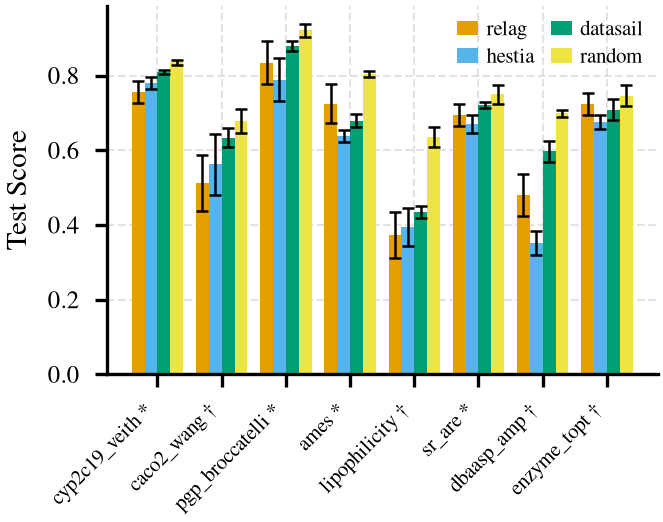

In [5]:
# Task type per dataset, from the evaluation metric used in the benchmark:
# AUROC -> classification, PCC -> regression. Marked on the x tick labels so the
# reader knows the bars within a panel are not all on a comparable score scale.
TASK = {
    # classification (AUROC)
    "cyp2c19_veith": "classification",
    "pgp_broccatelli": "classification",
    "ames": "classification",
    "sr_are": "classification",
    # regression (PCC)
    "caco2_wang": "regression",
    "lipophilicity": "regression",
    "dbaasp_amp": "regression",
    "enzyme_topt": "regression",
}
TASK_MARKER = {"classification": "*", "regression": "†"}


def plot_bar_combined(groups: list[tuple[str, str]], head: str = "mlp", methods: list[str] = METHODS):
    """groups: list of (modality, dataset) pairs, plotted left to right."""
    n_methods = len(methods)
    colors = method_colors(methods)
    x = np.arange(len(groups))
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for i, method in enumerate(methods):
        means, stds = [], []
        for modality, ds in groups:
            vals = get_test_values(modality, ds, method, head)
            means.append(np.nan if vals is None else vals.mean())
            stds.append(np.nan if vals is None else vals.std())
        offset = (i - (n_methods - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, label=method_label(method), color=colors[method],
              error_kw={"elinewidth": 0.6, "capsize": 1.5, "capthick": 0.6})

    unlabelled = [ds for _, ds in groups if ds not in TASK]
    if unlabelled:
        print(f"warning: no task type recorded for {unlabelled} -- left unmarked")

    labels = [f"{ds} {TASK_MARKER.get(TASK.get(ds), '')}".strip() for _, ds in groups]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=5)
    ax.tick_params(axis="y", labelsize=6)
    ax.set_ylabel(f"Test Score", fontsize=7)
    ax.legend(ncol=2, fontsize=5, loc="upper right", handlelength=1.0, handletextpad=0.4,
             columnspacing=0.8, labelspacing=0.3)
    fig.tight_layout()
    return fig, ax

groups = [("molecule", ds) for ds in MOLECULE_DATASETS] + [("protein", ds) for ds in PROTEIN_DATASETS]
fig, ax = plot_bar_combined(groups)
plt.show()
save_fig(fig, "perf_combined_mlp")

In [6]:
# ---- Leakage / min-distance-to-train data loading ---------------------------
# comparison/results/leakage/{modality}/{dataset}/{method}_seed1.npy holds, per
# test sample, its max identity to the nearest train sample (Tanimoto for
# molecules, sequence identity for protein/DNA) -- i.e. 1 - min_distance.
# Single seed by design (see comparison/README.md).
LEAK_DIR = BASE / "leakage"
LEAK_THRESHOLD = {"molecule": 0.40, "dna": 0.40, "protein": 0.50}

def load_leakage(modality: str, dataset: str, method: str) -> np.ndarray | None:
    path = LEAK_DIR / modality / dataset / f"{method}_seed1.npy"
    if not path.exists():
        return None
    return np.load(path)

print("leakage loader ready")

leakage loader ready


/tmp/ipykernel_1596178/2187252980.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


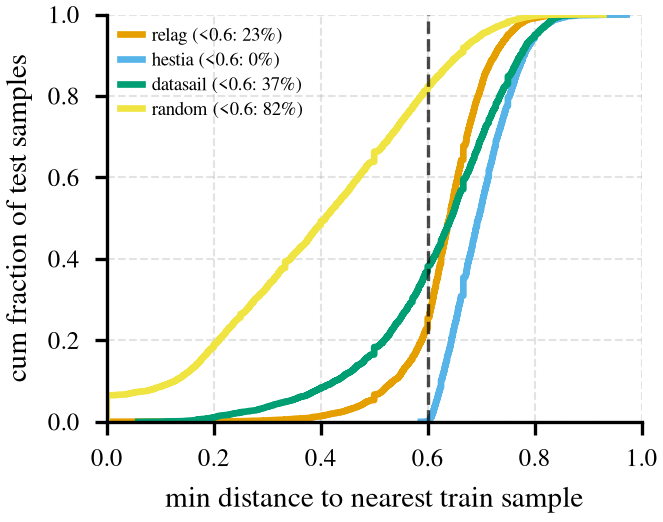

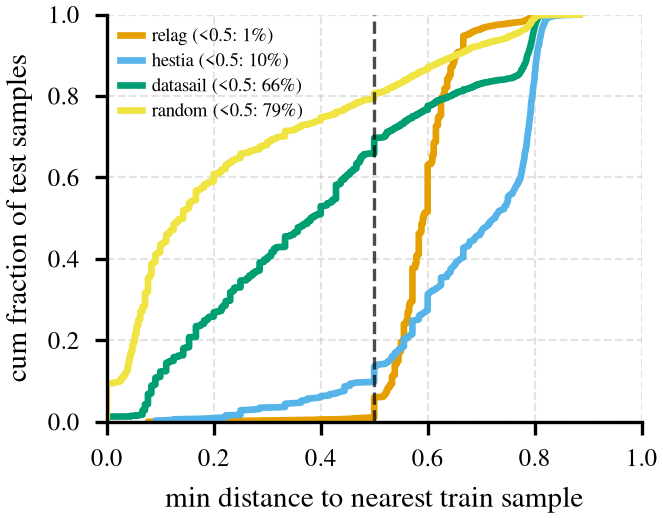

In [7]:
# ---- Draft C: ECDF combined across all datasets in a modality ---------------
# Concatenate the per-test-sample leakage arrays across every dataset of a
# modality (for each method) before computing the ECDF, so each modality gets
# a single pooled curve instead of one plot per dataset.

def plot_leakage_ecdf_combined(modality: str, datasets: list[str], methods: list[str] = METHODS):
    dist_threshold = 1.0 - LEAK_THRESHOLD[modality]
    colors = method_colors(methods)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for method in methods:
        pooled = []
        for dataset in datasets:
            identity = load_leakage(modality, dataset, method)
            if identity is None:
                continue
            pooled.append(identity)
        if not pooled:
            continue
        identity = np.concatenate(pooled)
        dist = 1.0 - identity
        x = np.sort(dist)
        y = np.arange(1, len(x) + 1) / len(x)
        frac_below = float((dist < dist_threshold).mean())
        ax.plot(x, y, color=colors[method], label=f"{method_label(method)} (<{dist_threshold:g}: {frac_below:.0%})")

    ax.axvline(dist_threshold, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlabel("min distance to nearest train sample", fontsize=7)
    ax.set_ylabel("cum fraction of test samples", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=4.5, handlelength=1.2, labelspacing=0.3, loc="upper left")
    fig.tight_layout()
    return fig, ax

fig, ax = plot_leakage_ecdf_combined("molecule", MOLECULE_DATASETS)
plt.show()
save_fig(fig, "leakage_ecdf_molecule")

fig, ax = plot_leakage_ecdf_combined("protein", PROTEIN_DATASETS)
plt.show()
save_fig(fig, "leakage_ecdf_protein")

In [8]:
# ---- Runtime scaling data loading --------------------------------------------

SCALING_DIR = Path("..") / "results" / "scaling"

def load_scaling(dataset: str) -> dict[str, dict[int, float | None]]:
    """{method: {size: runtime_s or None (failed)}} for one dataset (atlas/belka)."""
    out: dict[str, dict[int, float | None]] = {}
    for path in sorted(SCALING_DIR.glob(f"runtime_{dataset}_*.json")):
        rec = json.load(open(path))[0]
        out.setdefault(rec["method"], {})[rec["size"]] = rec["runtime_s"]
    return out

for ds in ("atlas", "belka"):
    print(ds, load_scaling(ds))

atlas {'hestia': {125000: 289.006, 25000: 20.894, 3125000: None, 5000: 9.491, 625000: 8754.983}, 'refnd': {125000: 183.525, 25000: 24.089, 3125000: 6220.371, 5000: 5.687, 625000: 1017.351}}
belka {'hestia': {125000: 5977.853, 15625000: None, 25000: 192.634, 3125000: None, 625000: None}, 'refnd': {125000: 8.828, 15625000: 1106.086, 25000: 7.149, 3125000: 155.474, 625000: 30.824}}


[atlas] fit parameters (log10(y) = polyval(coeffs, log10(x))):
  relag    linear_loglog      coeffs (high->low degree) = [1.102124285212086, -3.377091437495138]
  hestia   quadratic_loglog   coeffs (high->low degree) = [0.5826515707097086, -4.096403020758745, 8.134838579654296]
[belka] fit parameters (log10(y) = polyval(coeffs, log10(x))):
  relag    quadratic_loglog   coeffs (high->low degree) = [0.2457328689223723, -2.0437376750730785, 5.055323100492477]
  hestia   quadratic_loglog   coeffs (high->low degree) = [0.2014437886055619, 0.2216223095169953, -2.586249523702329]


/tmp/ipykernel_1596178/3889166624.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_1596178/3889166624.py:30: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(log_x, log_y, degree)


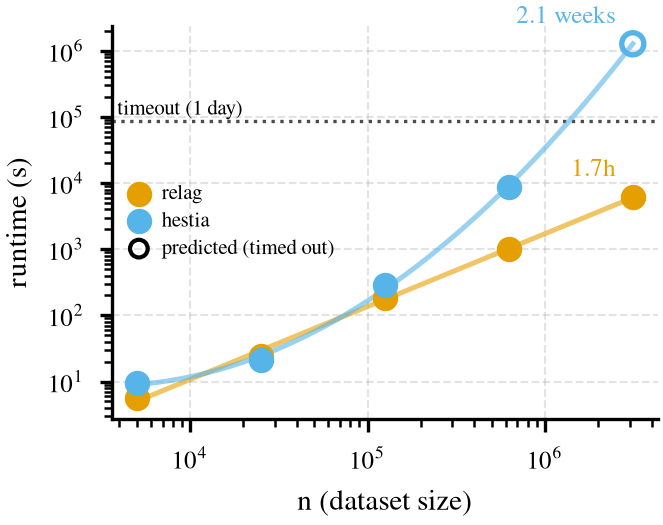

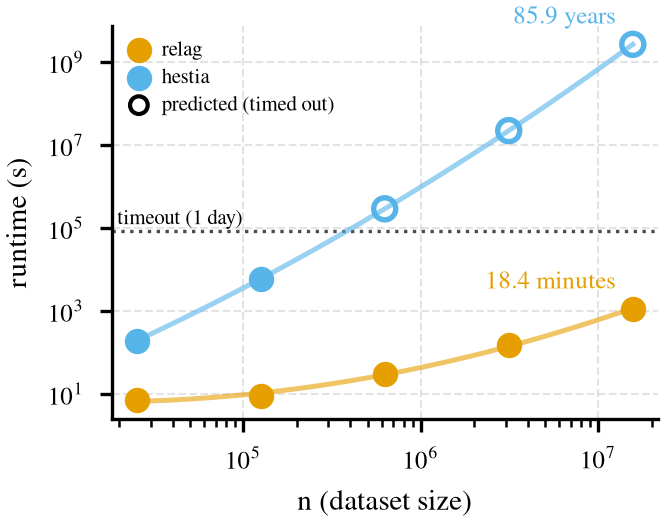

In [9]:
# ---- Runtime scaling: model fit per (dataset, method), hollow = predicted/timed out --
# hestia: quadratic in log-log space on both datasets (worse-than-n*log(n) clustering cost).
# relag:  linear (power law) on atlas -- build_s dominates there and fits a straight
#         line almost perfectly (R^2=0.998); quadratic on belka -- at belka's much
#         larger sizes, leiden_s's share of total runtime (which grows faster than
#         build_s's share, per the per-stage breakdown) becomes large enough to bend
#         the curve.

FIT_KIND = {
    ("atlas", "refnd"): "linear_loglog", ("atlas", "hestia"): "quadratic_loglog",
    ("belka", "refnd"): "quadratic_loglog", ("belka", "hestia"): "quadratic_loglog",
}
TIMEOUT_S = 24 * 3600  # 1 day

# Fixed display unit for the rightmost-point annotation, per (dataset, method) --
# chosen so the number reads naturally at that method's scale on that dataset;
# falls back to auto (days/hours) when not listed.
ANNOTATION_UNIT = {
    ("atlas", "hestia"): "weeks",
    ("belka", "hestia"): "years",
    ("belka", "refnd"): "minutes",
}
_SECONDS_PER_UNIT = {"minutes": 60, "hours": 3600, "days": 86400, "weeks": 7 * 86400, "years": 365.25 * 86400}

def _fit_predict(kind: str, sizes_ok: list[int], runtimes_ok: list[float]):
    x = np.array(sizes_ok, dtype=float)
    y = np.array(runtimes_ok, dtype=float)
    log_x, log_y = np.log10(x), np.log10(y)
    degree = {"linear_loglog": 1, "quadratic_loglog": 2}[kind]
    coeffs = np.polyfit(log_x, log_y, degree)
    predict = lambda xs: 10 ** np.polyval(coeffs, np.log10(xs))
    return predict, coeffs


def _format_duration(seconds: float, unit: str | None = None) -> str:
    if unit is not None:
        return f"{seconds / _SECONDS_PER_UNIT[unit]:.1f} {unit}"
    days = seconds / 86400
    if days >= 1:
        return f"{days:.1f}d"
    hours = seconds / 3600
    return f"{hours:.1f}h"


def plot_scaling(dataset: str, methods: list[str] = ("refnd", "hestia"), legend_loc="lower right"):
    data = load_scaling(dataset)
    colors = method_colors(list(methods))
    fit_params = {}

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_xscale("log")
    ax.set_yscale("log")

    for method in methods:
        sizes_all = sorted(data.get(method, {}))
        if not sizes_all:
            continue
        sizes_ok = [s for s in sizes_all if data[method][s] is not None]
        runtimes_ok = [data[method][s] for s in sizes_ok]

        kind = FIT_KIND[(dataset, method)]
        predict, coeffs = _fit_predict(kind, sizes_ok, runtimes_ok)
        fit_params[method] = {"kind": kind, "coeffs": coeffs.tolist()}

        # observed points: solid markers
        ax.scatter(sizes_ok, runtimes_ok, color=colors[method], s=28, zorder=3, label=method_label(method))

        # fit curve across the full observed size range
        x_fit = np.logspace(np.log10(min(sizes_all)), np.log10(max(sizes_all)), 200)
        ax.plot(x_fit, predict(x_fit), color=colors[method], linewidth=1.2, alpha=0.6, zorder=2)

        # timed-out sizes: hollow marker at the fit-predicted runtime
        sizes_missing = [s for s in sizes_all if data[method][s] is None]
        if sizes_missing:
            y_pred = predict(np.array(sizes_missing, dtype=float))
            ax.scatter(sizes_missing, y_pred, facecolors="none", edgecolors=colors[method],
                      s=28, linewidths=1.3, zorder=3)

        # annotate the rightmost (largest-n) point, real or predicted, with its runtime
        rightmost_size = sizes_all[-1]
        rightmost_y = data[method][rightmost_size]
        if rightmost_y is None:
            rightmost_y = float(predict(np.array([rightmost_size]))[0])
        unit = ANNOTATION_UNIT.get((dataset, method))
        ax.annotate(_format_duration(rightmost_y, unit), (rightmost_size, rightmost_y),
                   textcoords="offset points", xytext=(-4, 5), ha="right", fontsize=6,
                   color=colors[method])

    ax.axhline(TIMEOUT_S, color="black", linestyle=":", linewidth=0.8, alpha=0.7, zorder=1)
    ax.text(0.01, TIMEOUT_S, "timeout (1 day)", transform=ax.get_yaxis_transform(),
           fontsize=5, va="bottom", ha="left")

    # legend entry for the hollow-marker convention
    ax.scatter([], [], facecolors="none", edgecolors="black", s=18, linewidths=1.0,
              label="predicted (timed out)")

    ax.set_xlabel("n (dataset size)", fontsize=7)
    ax.set_ylabel("runtime (s)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(loc=legend_loc, fontsize=5, handlelength=1.2, labelspacing=0.3)
    fig.tight_layout()

    print(f"[{dataset}] fit parameters (log10(y) = polyval(coeffs, log10(x))):")
    for method, p in fit_params.items():
        print(f"  {method_label(method):8s} {p['kind']:18s} coeffs (high->low degree) = {p['coeffs']}")

    return fig, ax, fit_params

fig, ax, fit_params = plot_scaling("atlas", legend_loc="center left")
plt.show()
save_fig(fig, "scaling_atlas")

fig, ax, fit_params = plot_scaling("belka", legend_loc="upper left")
plt.show()
save_fig(fig, "scaling_belka")

In [14]:
# ---- Table: linear vs quadratic (log-log) fit R^2, per method x dataset -----

def _loglog_r2(sizes_ok: list[int], runtimes_ok: list[float], degree: int) -> float:
    log_x = np.log10(sizes_ok)
    log_y = np.log10(runtimes_ok)
    coeffs = np.polyfit(log_x, log_y, degree)
    pred = np.polyval(coeffs, log_x)
    ss_res = np.sum((log_y - pred) ** 2)
    ss_tot = np.sum((log_y - log_y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

rows = []
for dataset in ("atlas", "belka"):
    data = load_scaling(dataset)
    for method in ("refnd", "hestia"):
        sizes_all = sorted(data.get(method, {}))
        sizes_ok = [s for s in sizes_all if data[method][s] is not None]
        runtimes_ok = [data[method][s] for s in sizes_ok]
        if len(sizes_ok) < 4:  # need >= degree+2 points for a meaningful quadratic R^2
            r2_lin, r2_quad = np.nan, np.nan
        else:
            r2_lin = _loglog_r2(sizes_ok, runtimes_ok, 1)
            r2_quad = _loglog_r2(sizes_ok, runtimes_ok, 2)
        rows.append({
            "dataset": dataset, "method": method_label(method), "n_points": len(sizes_ok),
            "R2_linear": r2_lin, "R2_quadratic": r2_quad,
            "delta": (r2_quad - r2_lin) if len(sizes_ok) >= 4 else np.nan,
        })

import pandas as pd
fit_table = pd.DataFrame(rows)
fit_table

,dataset,method,n_points,R2_linear,R2_quadratic,delta
0,atlas,relag,5,0.998058,0.998451,0.000392
1,atlas,hestia,4,0.937695,0.998049,0.060354
2,belka,relag,5,0.937192,0.996963,0.059771
3,belka,hestia,2,NaN,NaN,NaN


stage                5,000      25,000     125,000     625,000   3,125,000    slope
HNSW build           1.267      13.754     119.752     747.562    3857.615     1.25
Leiden               0.005       0.040       0.232       2.212      40.000     1.37


/tmp/ipykernel_1596178/409124542.py:42: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


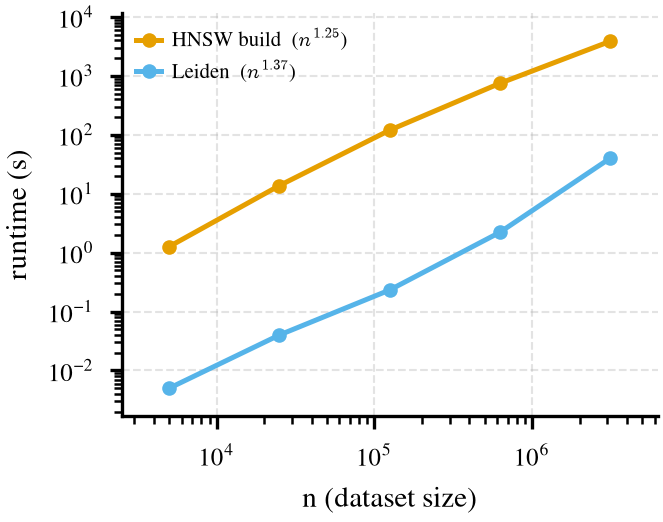

In [11]:
# ---- Runtime scaling: HNSW build vs. Leiden, per-stage timing ---------------
# results/scaling_detailed_refnd.json (debug_scaling_relag.py, peptide_atlas
# subsets). Restricted to the two stages that carry real signal: both are
# non-zero at every size measured, so every point survives the log-log axes.
# The other three stages (edges/graph/partition) round to 0.0 ms below n=10^5
# and are omitted rather than silently dropped.

with open(Path("..") / "results" / "scaling_detailed_refnd.json") as f:
    detailed = json.load(f)

STAGES = [
    ("build_s", "HNSW build"),
    ("leiden_s", "Leiden"),
]

def plot_scaling_detailed(records: list[dict]):
    sizes = np.array([r["size"] for r in records], dtype=float)
    colors = method_colors([k for k, _ in STAGES])

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_xscale("log")
    ax.set_yscale("log")

    slopes = {}
    for key, label in STAGES:
        y = np.array([r[key] for r in records], dtype=float)
        assert (y > 0).all(), f"{key} has non-positive values, cannot plot on log axes"
        slope, intercept = np.polyfit(np.log10(sizes), np.log10(y), 1)
        slopes[label] = slope
        ax.plot(sizes, y, marker="o", markersize=3.5, linewidth=1.2,
                color=colors[key], label=f"{label}  ($n^{{{slope:.2f}}}$)", zorder=3)

    # Pad the limits so no marker sits on the frame.
    ys = np.concatenate([[r[k] for r in records] for k, _ in STAGES]).astype(float)
    ax.set_xlim(sizes.min() / 2, sizes.max() * 2)
    ax.set_ylim(ys.min() / 3, ys.max() * 3)

    ax.set_xlabel("n (dataset size)", fontsize=7)
    ax.set_ylabel("runtime (s)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(loc="upper left", fontsize=5, handlelength=1.2, labelspacing=0.3)
    fig.tight_layout()

    print(f"{'stage':<14}" + "".join(f"{int(s):>12,}" for s in sizes) + f"{'slope':>9}")
    for key, label in STAGES:
        row = [r[key] for r in records]
        print(f"{label:<14}" + "".join(f"{v:>12.3f}" for v in row) + f"{slopes[label]:>9.2f}")
    return fig, ax

fig, ax = plot_scaling_detailed(detailed)
plt.show()
save_fig(fig, "scaling_detailed_refnd")


stage               25,000     125,000     625,000   3,125,000  15,625,000    slope
HNSW build           0.181       1.123      10.931      76.699     422.668     1.23
Leiden               0.010       0.054       0.339       3.869      30.998     1.26


/tmp/ipykernel_1596178/409124542.py:42: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


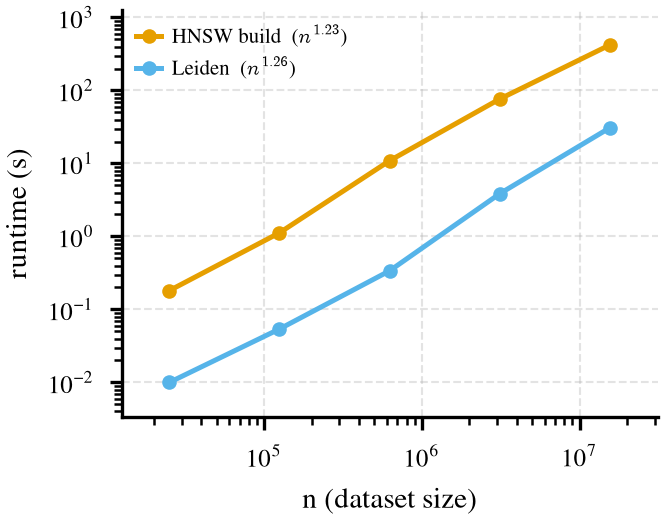

In [12]:
# ---- Runtime scaling: HNSW build vs. Leiden, per-stage timing ---------------
# Same figure as above, on belka subsets (results/scaling_detailed_refnd_belka.json)
# rather than peptide_atlas. Reuses plot_scaling_detailed / STAGES from the
# previous cell; both stages are again non-zero at every size, so no point is
# dropped by the log-log axes.

with open(Path("..") / "results" / "scaling_detailed_refnd_belka.json") as f:
    detailed_belka = json.load(f)

fig, ax = plot_scaling_detailed(detailed_belka)
plt.show()
save_fig(fig, "scaling_detailed_refnd_belka")


In [13]:
# ---- Table: log-scale gap between the HNSW build and Leiden curves ----------
# The vertical distance between the two curves in the two figures above, i.e.
# log10(build_s) - log10(leiden_s) = log10(build_s / leiden_s). A gap of 1.0
# means build is one full decade (10x) above Leiden on the log axis. Also
# reported as the raw ratio, which is the same number read linearly.

gap_rows = []
for dataset, records in (("atlas", detailed), ("belka", detailed_belka)):
    for r in records:
        build, leiden = r["build_s"], r["leiden_s"]
        gap = np.log10(build) - np.log10(leiden)
        gap_rows.append({
            "dataset": dataset,
            "n": r["size"],
            "build_s": build,
            "leiden_s": leiden,
            "log10_gap": gap,
            "ratio": build / leiden,
        })

gap_table = pd.DataFrame(gap_rows)
gap_table


,dataset,n,build_s,leiden_s,log10_gap,ratio
0,atlas,5000,1.267,0.005,2.403807,253.400000
1,atlas,25000,13.754,0.040,2.536369,343.850000
2,atlas,125000,119.752,0.232,2.712795,516.172414
3,atlas,625000,747.562,2.212,2.528862,337.957505
4,atlas,3125000,3857.615,40.000,1.984259,96.440375
5,belka,25000,0.181,0.010,1.257679,18.100000
6,belka,125000,1.123,0.054,1.317986,20.796296
7,belka,625000,10.931,0.339,1.508460,32.244838
8,belka,3125000,76.699,3.869,1.297191,19.823986
9,belka,15625000,422.668,30.998,1.134666,13.635331


/tmp/ipykernel_1637086/3772279394.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_1637086/3772279394.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


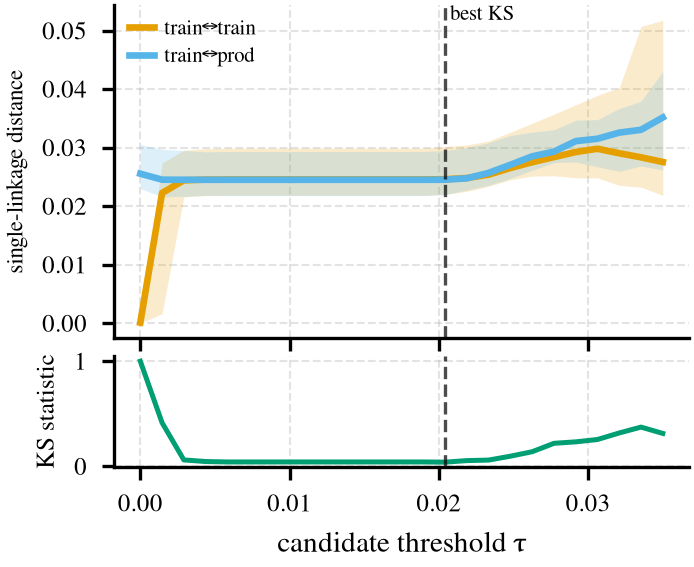

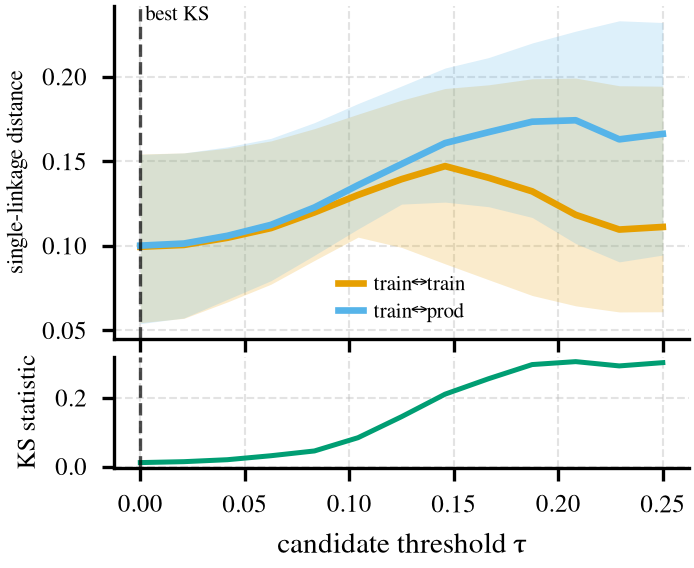

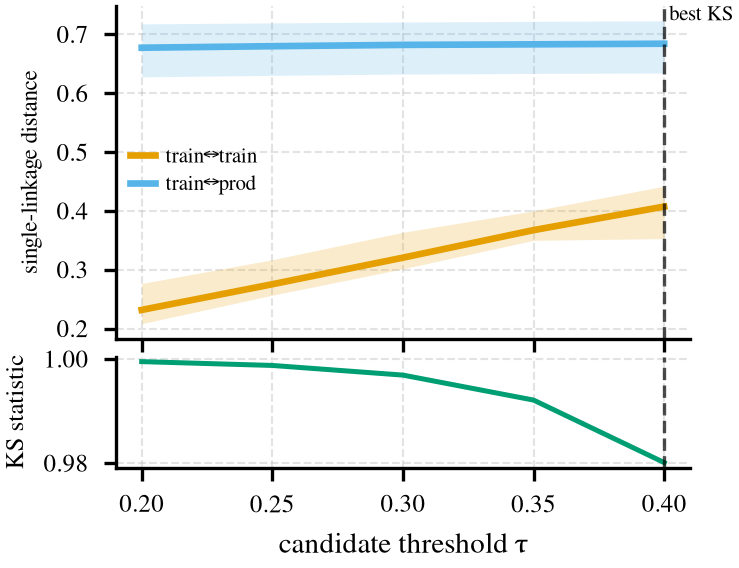

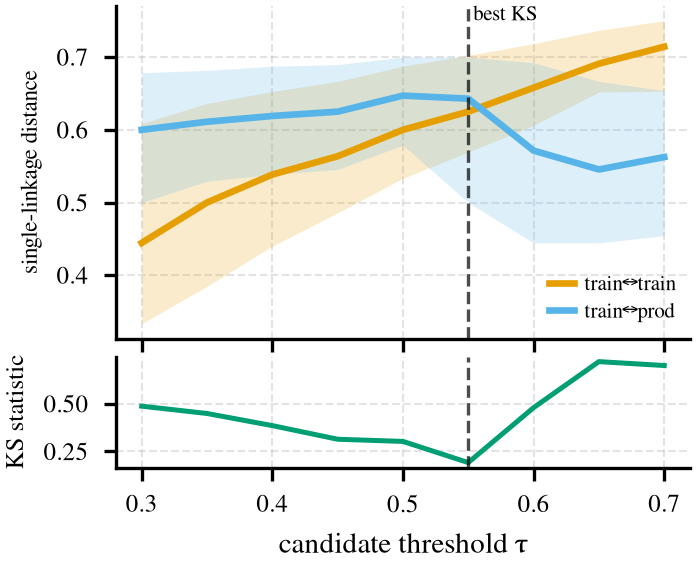

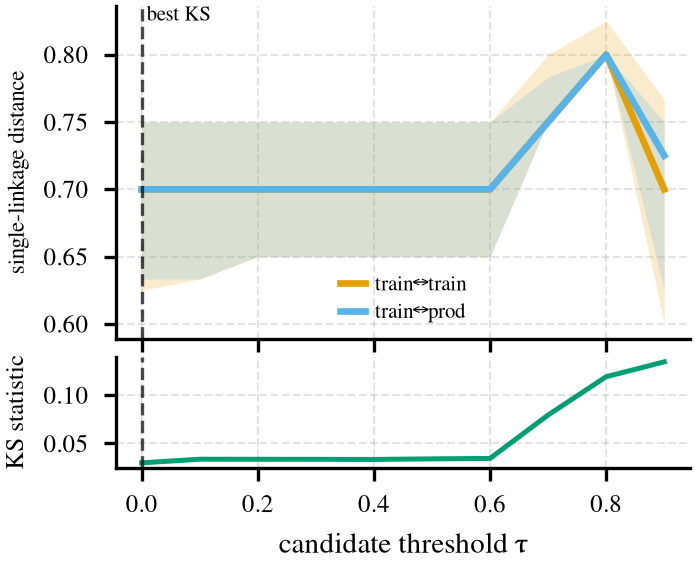

In [8]:
# ---- Threshold section: train-train vs train-prod single-linkage distance ---
# distribution (median + p15-p85 spread) across candidate thresholds, with a
# shared-x panel underneath showing the KS statistic at each threshold.
# Handles both formats found under results/thresholds/: synthetic.json has
# top-level thresholds[]/best_threshold_ks; the rest (mnist/molecules/peptides/
# uniref.json) only have results[], each carrying its own "threshold" -- derive
# both from there.

THRESH_DIR = Path("..") / "results" / "thresholds"

def load_threshold_sweep(name: str) -> dict:
    with open(THRESH_DIR / f"{name}.json") as f:
        return json.load(f)

def plot_threshold_spread(name: str):
    d = load_threshold_sweep(name)
    results = sorted(d["results"], key=lambda r: r["threshold"])
    thresholds = np.array(d.get("thresholds", [r["threshold"] for r in results]))
    ks_stats = np.array([r["ks_stat"] for r in results])
    best_threshold_ks = d.get("Okay", float(thresholds[np.argmin(ks_stats)]))

    colors = method_colors(["refnd", "hestia"])
    ks_color = _cycle_colors[2]

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(FIG_W, FIG_H), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    )

    for key, label, color in (
        ("train_train", "train↔train", colors["refnd"]),
        ("train_prod", "train↔prod", colors["hestia"]),
    ):
        median = np.array([r[key]["median"] for r in results])
        p15 = np.array([r[key]["p15"] for r in results])
        p85 = np.array([r[key]["p85"] for r in results])
        ax_top.plot(thresholds, median, color=color, label=label)
        ax_top.fill_between(thresholds, p15, p85, color=color, alpha=0.2, linewidth=0)

    ax_top.axvline(best_threshold_ks, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax_top.text(best_threshold_ks, ax_top.get_ylim()[1], " best KS", fontsize=5, va="top", ha="left")
    ax_top.set_ylabel("single-linkage distance", fontsize=5.5)
    # ax_top.set_title(f"{name}", fontsize=7)
    ax_top.tick_params(labelsize=6)
    ax_top.legend(fontsize=5, handlelength=1.2, labelspacing=0.3)

    ax_bot.plot(thresholds, ks_stats, color=ks_color, linewidth=1.2)
    ax_bot.axvline(best_threshold_ks, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax_bot.set_ylabel("KS statistic", fontsize=6)
    ax_bot.set_xlabel("candidate threshold τ", fontsize=7)
    ax_bot.tick_params(labelsize=6)

    fig.tight_layout()
    return fig, (ax_top, ax_bot)

for dataset_name in ("synthetic", "mnist", "molecules", "peptides", "uniref"):
    fig, axes = plot_threshold_spread(dataset_name)
    plt.show()
    save_fig(fig, f"threshold_spread_{dataset_name}")

/tmp/ipykernel_1637086/4245157610.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


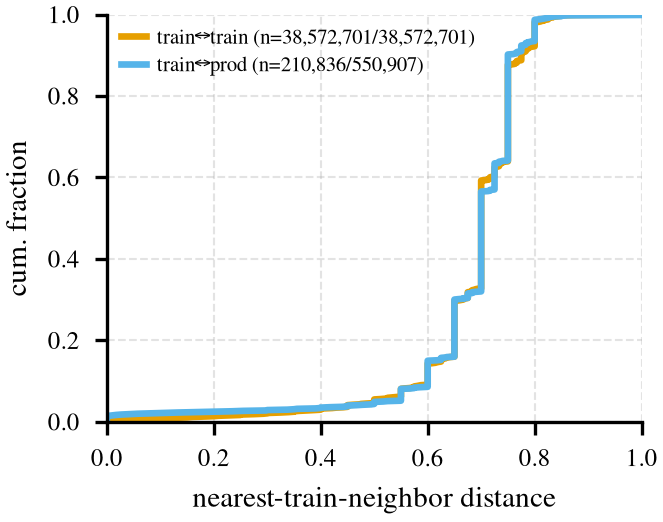

In [9]:
# ---- uniref: real node-level ECDF, from threshold/uniref_investigation.py --
# Full nearest-train-neighbor distance ECDF (1000-level quantile function per
# group)
with open(THRESH_DIR / "unirefxbenchmark_ecdf.json") as f:
    ecdf_data = json.load(f)

def plot_ecdf_from_quantiles(d: dict):
    colors = method_colors(["refnd", "hestia"])
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for key, label, color in (
        ("train_train", "train↔train", colors["refnd"]),
        ("train_prod", "train↔prod", colors["hestia"]),
    ):
        q = d[key]
        ax.plot(q["values"], q["levels"], color=color,
               label=f"{label} (n={q['n_finite']:,}/{q['n_raw']:,})")

    ax.set_xlabel("nearest-train-neighbor distance", fontsize=7)
    ax.set_ylabel("cum. fraction", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=5, handlelength=1.2, labelspacing=0.3)
    fig.tight_layout()
    return fig, ax

fig, ax = plot_ecdf_from_quantiles(ecdf_data)
plt.show()
save_fig(fig, "uniref_benchmark_ecdf")

In [10]:
# ---- Table: percentile comparison, train<->train vs train<->prod -----------

PERCENTILES = [1, 5, 10, 25, 50, 75, 90, 95, 99]

def percentile_table(d: dict) -> pd.DataFrame:
    rows = []
    for p in PERCENTILES:
        level = p / 100.0
        tt = float(np.interp(level, d["train_train"]["levels"], d["train_train"]["values"]))
        tp = float(np.interp(level, d["train_prod"]["levels"], d["train_prod"]["values"]))
        rows.append({
            "percentile": p,
            "train↔train": tt,
            "train↔prod": tp,
            "prod - train": tp - tt,
        })
    return pd.DataFrame(rows)

pct_table = percentile_table(ecdf_data)
pct_table

,percentile,train↔train,train↔prod,prod - train
0,1,0.127046,0.000000,-0.127046
1,5,0.500000,0.515833,0.015833
2,10,0.600000,0.600000,0.000000
3,25,0.650000,0.650000,0.000000
4,50,0.700000,0.700000,0.000000
5,75,0.750000,0.750000,0.000000
6,90,0.775000,0.750000,-0.025000
7,95,0.800000,0.800000,0.000000
8,99,0.825000,0.816700,-0.008300


/tmp/ipykernel_1637086/1582218765.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


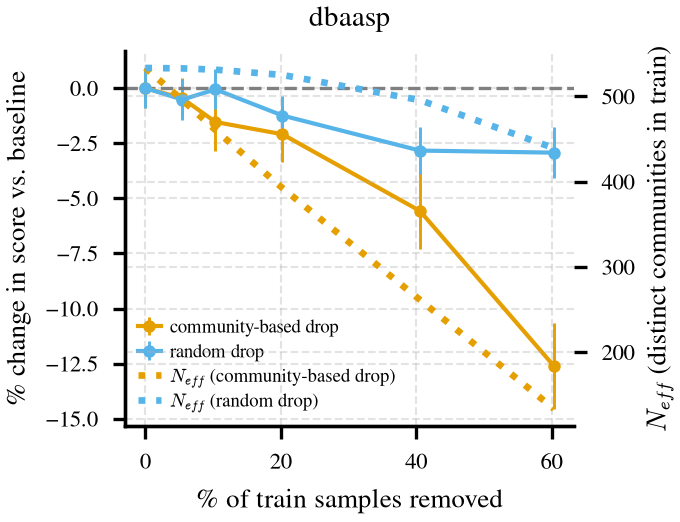

In [11]:
# ---- Data starvation: score vs. % of train samples removed -----------------
STARVE_DIR = Path("..") / "results" / "data_starvation"


def load_starvation(dataset: str) -> dict:
    with open(STARVE_DIR / f"{dataset}.json") as f:
        return json.load(f)


def plot_starvation(dataset: str):
    d = load_starvation(dataset)
    n_train = d["n_train"]
    by_frac = d["by_drop_fraction"]
    n_repeats = d["n_repeats"]

    drop_fracs = sorted(by_frac.keys(), key=float)
    pct_removed = [100.0 * by_frac[k]["n_dropped_mean"] / n_train for k in drop_fracs]

    baseline_key = min(drop_fracs, key=float)
    baseline = by_frac[baseline_key]["community_score_mean"]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    score_lines = {}
    for key, label in [("community_score", "community-based drop"), ("random_score", "random drop")]:
        means = np.array([by_frac[k][f"{key}_mean"] for k in drop_fracs])
        stds = np.array([by_frac[k][f"{key}_std"] for k in drop_fracs])
        pct_change = 100.0 * (means - baseline) / baseline
        err = 100.0 * (stds / np.sqrt(n_repeats)) / baseline
        line = ax.errorbar(pct_removed, pct_change, yerr=err, marker="o", markersize=3,
                          linewidth=1, capsize=2, elinewidth=0.7, label=label)
        score_lines[key] = line[0].get_color()

    ax.axhline(0.0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("% of train samples removed", fontsize=6.5)
    ax.set_ylabel("% change in score vs. baseline", fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax_eff = ax.twinx()
    for key, label, color in [
        ("n_eff_community", "$N_{eff}$ (community-based drop)", score_lines["community_score"]),
        ("n_eff_random", "$N_{eff}$ (random drop)", score_lines["random_score"]),
    ]:
        n_eff = [by_frac[k][f"{key}_mean"] for k in drop_fracs]
        ax_eff.plot(pct_removed, n_eff, linestyle=":", marker="none", color=color, label=label)
    ax_eff.set_ylabel("$N_{eff}$ (distinct communities in train)", fontsize=6.5)
    ax_eff.tick_params(labelsize=5.5)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_eff.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=4.5, handlelength=1.2, labelspacing=0.3, loc="best")

    ax.set_title(dataset, fontsize=7)
    fig.tight_layout()
    return fig, (ax, ax_eff)


fig, axes = plot_starvation("dbaasp")
plt.show()
save_fig(fig, "data_starvation")

/tmp/ipykernel_1637086/1582218765.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


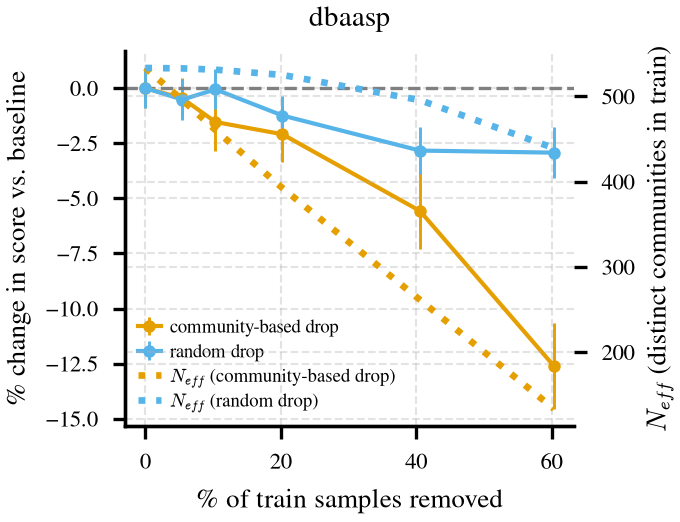

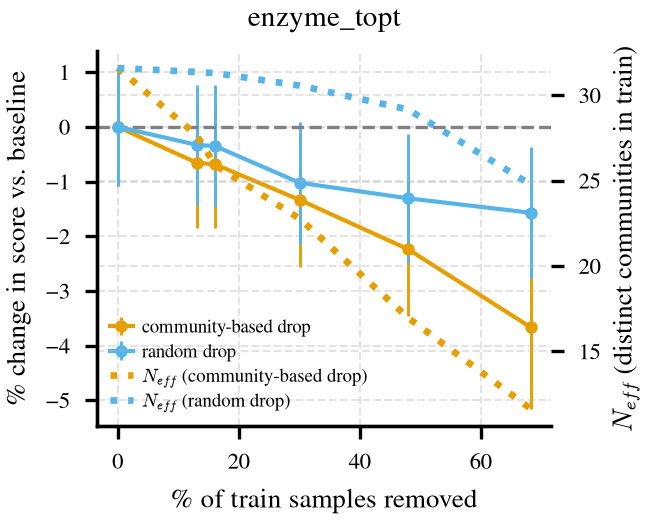

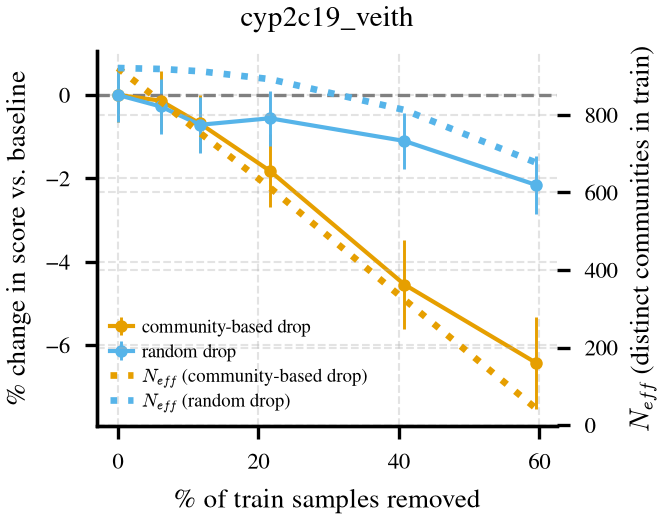

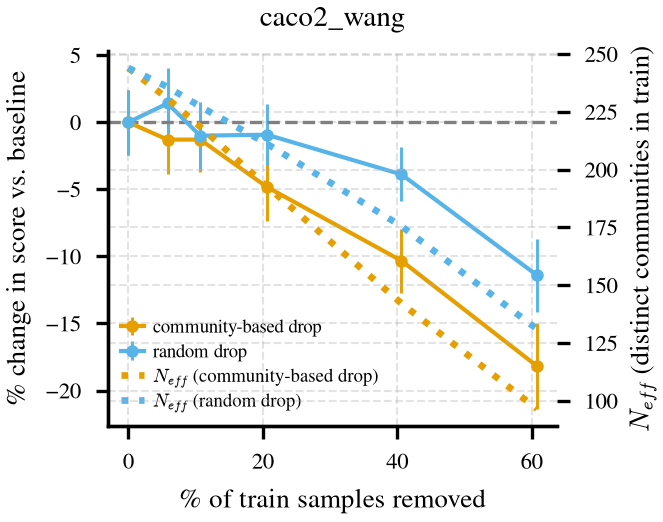

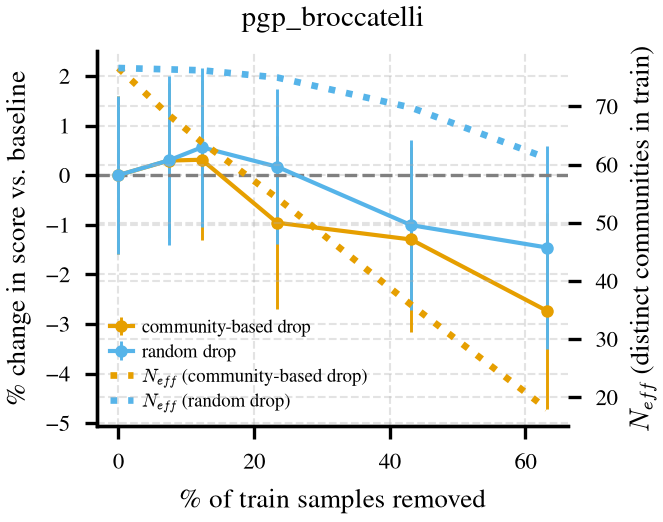

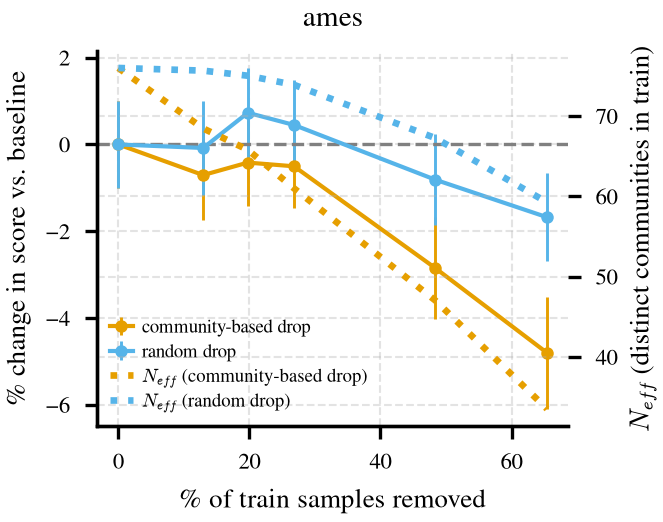

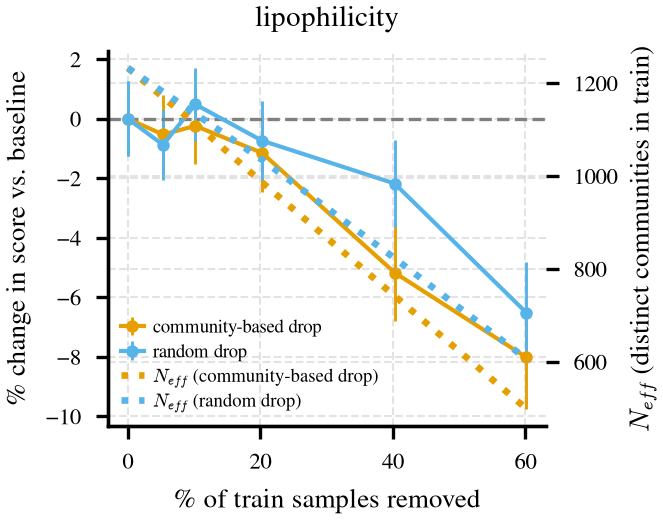

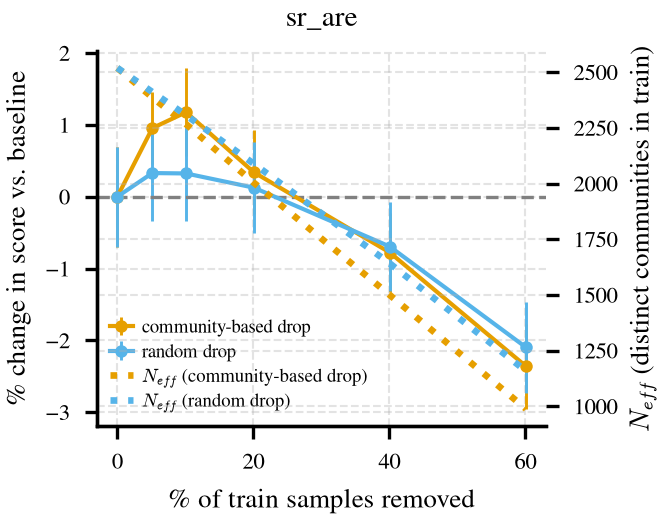

In [12]:
# ---- Data starvation: the other datasets (same plot as dbaasp) ----------
STARVATION_DATASETS = [
    "dbaasp", "enzyme_topt", "cyp2c19_veith", "caco2_wang",
    "pgp_broccatelli", "ames", "lipophilicity", "sr_are",
]

for ds in STARVATION_DATASETS:
    fig, axes = plot_starvation(ds)
    save_fig(fig, f"data_starvation_{ds}")
    plt.show()


/tmp/ipykernel_1596178/1268847842.py:60: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.7)  # room for labels without extending the x-range


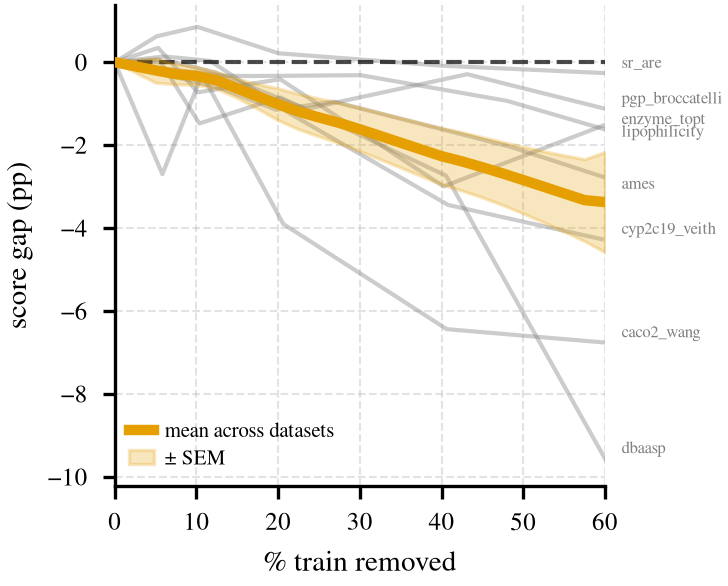

In [20]:
# ---- Data starvation: compressed single-figure summary across all datasets --
# The 8 per-dataset panels above all carry the same message at different score
# scales: community-based drop underperforms random drop, and the gap grows
# with more removed. Collapse each dataset to one curve -- gap(%removed) =
# community_pct_change - random_pct_change (<0 means community-drop hurts
# more) -- then overlay all datasets as thin lines (plotted to their own true
# extent) plus one bold mean +/- SEM band (computed on a shared interpolation
# grid). Each label is anchored at its own true value (no displacement, no
# leader line needed) -- default va="bottom" puts the text above its line;
# lipophilicity uses va="top" (text below its line) since it sits just under
# sr_are, avoiding a collision without moving either label off its true spot.

def starvation_gap(dataset: str) -> tuple[np.ndarray, np.ndarray]:
    d = load_starvation(dataset)
    n_train = d["n_train"]
    by_frac = d["by_drop_fraction"]
    drop_fracs = sorted(by_frac.keys(), key=float)
    pct_removed = np.array([100.0 * by_frac[k]["n_dropped_mean"] / n_train for k in drop_fracs])

    baseline = by_frac[min(drop_fracs, key=float)]["community_score_mean"]
    community = np.array([by_frac[k]["community_score_mean"] for k in drop_fracs])
    random_ = np.array([by_frac[k]["random_score_mean"] for k in drop_fracs])
    community_pct = 100.0 * (community - baseline) / baseline
    random_pct = 100.0 * (random_ - baseline) / baseline
    return pct_removed, community_pct - random_pct


def plot_starvation_gap_combined(datasets: list[str], grid_max: float = 60.0, n_grid: int = 25):
    grid = np.linspace(0, grid_max, n_grid)
    gap_matrix = np.full((len(datasets), n_grid), np.nan)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    color = _cycle_colors[0]

    label_pts = []
    for i, dataset in enumerate(datasets):
        pct_removed, gap = starvation_gap(dataset)
        ax.plot(pct_removed, gap, color="grey", alpha=0.4, linewidth=1)
        # np.interp flat-extrapolates past a dataset's own last point, so every
        # dataset gets a well-defined y at grid_max regardless of its true extent
        label_pts.append((dataset, float(np.interp(grid_max, pct_removed, gap))))
        valid = grid <= pct_removed.max()
        gap_matrix[i, valid] = np.interp(grid, pct_removed, gap)[valid]

    mean_gap = np.nanmean(gap_matrix, axis=0)
    n_valid = np.sum(~np.isnan(gap_matrix), axis=0)
    sem_gap = np.nanstd(gap_matrix, axis=0) / np.sqrt(np.maximum(n_valid, 1))
    ax.plot(grid, mean_gap, color=color, linewidth=2.5, label="mean across datasets", zorder=5)
    ax.fill_between(grid, mean_gap - sem_gap, mean_gap + sem_gap, color=color, alpha=0.25,
                    label="± SEM", zorder=4)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)

    for dataset, y in label_pts:
        va = "top" if dataset == "lipophilicity" or dataset == "ames" else "bottom"
        ax.annotate(dataset, (grid_max, y), fontsize=4, color="grey", xytext=(4, 0),
                   textcoords="offset points", va=va)

    ax.set_xlim(0, grid_max)
    ax.margins(x=0)
    fig.subplots_adjust(right=0.7)  # room for labels without extending the x-range
    ax.set_xlabel("% train removed", fontsize=7)
    ax.set_ylabel("score gap (pp)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=5, loc="lower left", handlelength=1.2, labelspacing=0.3)
    return fig, ax


fig, ax = plot_starvation_gap_combined(STARVATION_DATASETS)
plt.show()
save_fig(fig, "data_starvation_gap_combined")


pooled Pearson r=0.455  R²=0.207  p=3.15e-03


/tmp/ipykernel_1596178/2700417214.py:57: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


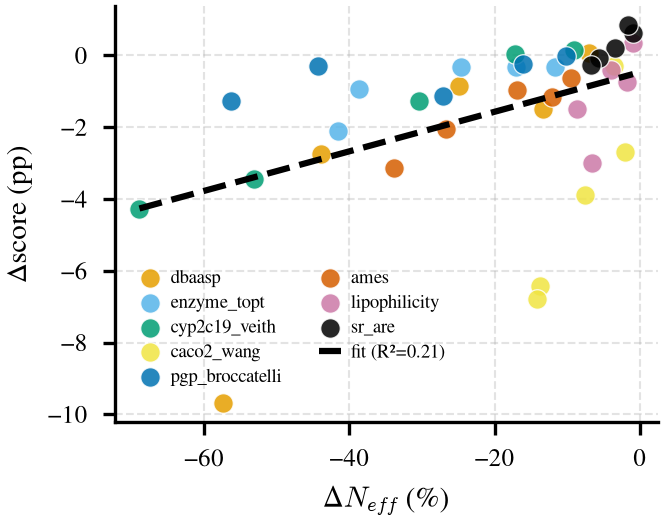

In [21]:
# ---- Data starvation: score gap vs. n_eff gap scatter, pooled across datasets --
# For each (dataset, drop-fraction step), plot the community-vs-random score gap
# (same quantity as the combined-gap plot above) against the analogous n_eff gap
# (pct change in n_eff for community-based drop minus random drop). Pooling all
# steps across all 8 datasets into one scatter tests whether a larger effective-
# community collapse (n_eff gap more negative) predicts a larger score gap.

from scipy.stats import pearsonr


def starvation_neff_gap(dataset: str) -> tuple[np.ndarray, np.ndarray]:
    d = load_starvation(dataset)
    by_frac = d["by_drop_fraction"]
    drop_fracs = sorted(by_frac.keys(), key=float)
    n_train = d["n_train"]
    pct_removed = np.array([100.0 * by_frac[k]["n_dropped_mean"] / n_train for k in drop_fracs])

    baseline = by_frac[min(drop_fracs, key=float)]["n_eff_community_mean"]
    n_eff_community = np.array([by_frac[k]["n_eff_community_mean"] for k in drop_fracs])
    n_eff_random = np.array([by_frac[k]["n_eff_random_mean"] for k in drop_fracs])
    community_pct = 100.0 * (n_eff_community - baseline) / baseline
    random_pct = 100.0 * (n_eff_random - baseline) / baseline
    return pct_removed, community_pct - random_pct


def plot_score_gap_vs_neff_gap_scatter(datasets: list[str]):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    all_x, all_y = [], []
    for i, dataset in enumerate(datasets):
        _, score_gap = starvation_gap(dataset)
        _, neff_gap = starvation_neff_gap(dataset)
        # drop the baseline (0, 0) point -- it's identical across all datasets
        # and would just pile up at the origin without adding information
        x, y = neff_gap[1:], score_gap[1:]
        color = _cycle_colors[i % len(_cycle_colors)]
        ax.scatter(x, y, s=22, color=color, alpha=0.85, edgecolor="white",
                   linewidth=0.3, label=dataset)
        all_x.append(x)
        all_y.append(y)

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    r, p = pearsonr(all_x, all_y)
    r2 = r ** 2
    print(f"pooled Pearson r={r:.3f}  R²={r2:.3f}  p={p:.2e}")

    slope, intercept = np.polyfit(all_x, all_y, 1)
    x_fit = np.array([all_x.min(), all_x.max()])
    ax.plot(x_fit, slope * x_fit + intercept, color="black", linestyle="--",
           linewidth=1.5, label=f"fit (R²={r2:.2f})")

    ax.set_xlabel(r"$ΔN_{eff}$ (%)", fontsize=7)
    ax.set_ylabel("Δscore (pp)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=4.5, handlelength=1.2, labelspacing=0.3, loc="lower left", ncol=2, bbox_to_anchor=(0.02, 0.05))
    fig.tight_layout()
    return fig, ax


fig, ax = plot_score_gap_vs_neff_gap_scatter(STARVATION_DATASETS)
plt.show()
save_fig(fig, "data_starvation_gap_scatter")


In [22]:
# ---- Table: singleton vs. community-matched train samples, per dataset -----
# results/data_starvation/singleton_power/summary.json: for each dataset, an
# MLP trained on n singleton-community train samples vs. an MLP trained on an
# equal-sized (n_nonsingleton_train_matched_mean == n_singleton_train_mean),
# community-matched sample of non-singleton train points. diff_mean =
# singleton_score - nonsingleton_score; significant = two-sided t-test p<0.05.
# Verdict: whether singletons carry significantly more signal than an
# equal-sized community sample, significantly less (communities more
# informative here), or the two are statistically indistinguishable (noise).

with open(STARVE_DIR / "singleton_power" / "summary.json") as f:
    singleton_power = json.load(f)

def _verdict(row: dict) -> str:
    if not row["significant"]:
        return "no difference (noise)"
    return "singleton > community" if row["diff_mean"] > 0 else "community > singleton"

singleton_rows = []
for dataset, d in singleton_power.items():
    singleton_rows.append({
        "dataset": dataset,
        "metric": d["metric"],
        "threshold": d["threshold"],
        "n_matched": d["n_singleton_train_mean"],
        "singleton_score": d["singleton_score_mean"],
        "community_score": d["nonsingleton_score_mean"],
        "diff (singleton - community)": d["diff_mean"],
        "p_value": d["p_value"],
        "verdict": _verdict(d),
    })

singleton_table = pd.DataFrame(singleton_rows).sort_values(
    "diff (singleton - community)", ascending=False).reset_index(drop=True)
singleton_table


,dataset,metric,threshold,n_matched,singleton_score,community_score,diff (singleton - community),p_value,verdict
0,caco2_wang,pcc,0.6,107.8,0.473009,0.417305,0.055704,0.010822,singleton > community
1,lipophilicity,pcc,0.4,949.4,0.539618,0.499764,0.039854,0.000026,singleton > community
2,sr_are,auroc,0.4,1922.8,0.710128,0.681532,0.028596,0.000001,singleton > community
3,pgp_broccatelli,auroc,0.6,173.2,0.817439,0.830331,-0.012892,0.381742,no difference (noise)
4,cyp2c19_veith,auroc,0.5,3247.8,0.779181,0.795691,-0.016509,0.037885,community > singleton
5,enzyme_topt,pcc,0.8,66.6,0.573293,0.602472,-0.029179,0.174744,no difference (noise)
6,dbaasp,pcc,0.3,1333.0,0.483414,0.520128,-0.036714,0.000013,community > singleton
7,ames,auroc,0.7,91.6,0.530434,0.639800,-0.109366,0.000088,community > singleton


n pairs  = 39,380
Pearson  r = 0.954
Spearman r = 0.911


/tmp/ipykernel_1596178/1336819484.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


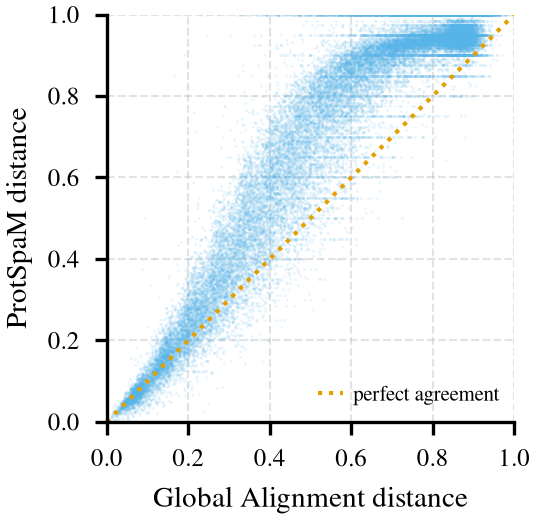

In [23]:
# ---- ProtSpaM vs. global alignment: mutation-ladder scatter -----------------
# Pairs from threshold/protspam_vs_alignment.py: real UniRef50 seeds mutated at
# a sweep of rates (BLOSUM62 substitutions + indels) so the alignment axis is
# covered end to end, each pair scored with both kernels.
from scipy.stats import pearsonr, spearmanr

with open(Path("..") / "results" / "protspam_vs_alignment.json") as f:
    pva = json.load(f)

ga, ps = np.asarray(pva["pairs"]).T
colors = method_colors(["refnd", "hestia"])

r_p, _ = pearsonr(ga, ps)
r_s, _ = spearmanr(ga, ps)
print(f"n pairs  = {len(ga):,}")
print(f"Pearson  r = {r_p:.3f}")
print(f"Spearman r = {r_s:.3f}")

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.scatter(ga, ps, s=0.5, alpha=0.12, linewidths=0, color=colors["hestia"], rasterized=True)
ax.plot([0, 1], [0, 1], ls=":", lw=1.0, color=colors["refnd"], label="perfect agreement")

ax.set_xlabel("Global Alignment distance", fontsize=7)
ax.set_ylabel("ProtSpaM distance", fontsize=7)
ax.tick_params(labelsize=6)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(fontsize=5, handlelength=1.2, labelspacing=0.3, loc="lower right")
fig.tight_layout()
plt.show()
save_fig(fig, "protspam_vs_alignment")


## Synthetic forest — split comparison

Results of `synthetic/compare_splits.py`: an annotated and a production dataset drawn independently from the same generator (15,000 peptides, 1,000 families each), so every production family is unseen. The label is the mechanistic signal `f(sequence)` plus small noise — there is no per-family effect, so any gap between test and production comes from sequence-level leakage alone. Each of the 100 repeats draws a fresh annotated + production pair.

- **Figure 1** — test vs. production PCC per split method.
- **Figure 2** — leakage: distance of each test sample to its nearest train sample.
- **Figure 3** — eval faithfulness: Test PCC − Production PCC per repeat.
- **Figure 4** — how τ is chosen on the synthetic forest.

In [24]:
# ---- Synthetic forest: data loading -----------------------------------------
# One results file, two blocks: records (one per method/repeat) and
# nn_distances (test -> nearest train, same keys).
# Each repeat draws a FRESH annotated + production pair, so the spread shown in
# every figure below covers dataset variation as well as split variation.
# The filename encodes tau, which synthetic/compare_splits.py derives from its
# TAU constant -- change SYN_TAU_FILE to look at a different threshold's sweep.

SYN_TAU_FILE = 0.5
SYN_RESULTS_PATH = (Path("..") / "results" / "synthetic"
                    / f"compare_splits_tau{SYN_TAU_FILE:g}.json")

with open(SYN_RESULTS_PATH) as f:
    synthetic = json.load(f)

SYN_SETTINGS = synthetic["settings"]
SYN_TAU = SYN_SETTINGS["tau"]

syn_records = pd.DataFrame([r for r in synthetic["records"] if r["error"] is None])

# Keep the notebook's colour for the four real methods; the oracle takes the next slot.
SYN_METHODS = ["random", "refnd", "hestia", "datasail", "family_oracle"]
SYN_COLOR = method_colors(METHODS + ["family_oracle"])
SYN_LABEL = {**METHOD_LABEL, "family_oracle": "oracle"}
syn_name = lambda method: SYN_LABEL.get(method, method)

print(f"{SYN_RESULTS_PATH.name}")
print(f"tau={SYN_TAU}  N={SYN_SETTINGS['n_peptides']:,}  "
      f"families={SYN_SETTINGS['n_families']:,}  repeats={SYN_SETTINGS['n_repeats']}")
print(f"{len(syn_records)} records, {len(synthetic['records']) - len(syn_records)} failed")
print(syn_records.groupby("method").size())

compare_splits_tau0.5.json
tau=0.5  N=15,000  families=1,000  repeats=100
500 records, 0 failed
method
datasail         100
family_oracle    100
hestia           100
random           100
refnd            100
dtype: int64


In [25]:
# ---- relag family recovery: ARI of communities vs true families -------------
# Adjusted Rand index between relag's Leiden communities and the generated
# families, on each repeat's annotated dataset (1 = perfect recovery, 0 = chance).

syn_ari = syn_records.loc[syn_records["method"] == "refnd", "ari"].astype(float)
print(f"relag ARI over {len(syn_ari)} repeats: "
      f"mean={syn_ari.mean():.3f}  std={syn_ari.std():.3f}  "
      f"[min={syn_ari.min():.3f}, max={syn_ari.max():.3f}]")

relag ARI over 100 repeats: mean=0.991  std=0.006  [min=0.967, max=0.999]


--- mean +/- std over repeats ---
method                      test        production  gap (mean)  median gap
random         0.858 +/-0.010  0.735 +/-0.014       +0.123      +0.124
relag          0.735 +/-0.026  0.730 +/-0.014       +0.005      +0.006
hestia         0.728 +/-0.031  0.732 +/-0.014       -0.004      -0.004
datasail       0.746 +/-0.027  0.742 +/-0.015       +0.004      +0.009
oracle         0.725 +/-0.032  0.731 +/-0.015       -0.006      -0.006


/tmp/ipykernel_1596178/2926613362.py:35: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


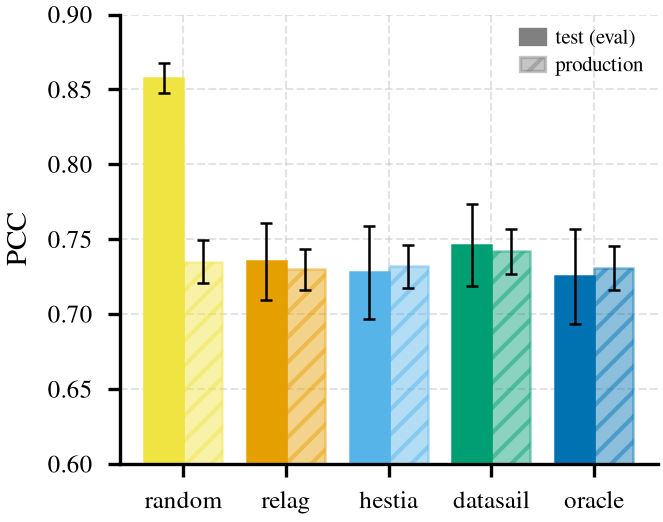

In [26]:
# ---- Figure 1: test vs production PCC, one bar group per split method -------
# Solid bar = annotated test split, hatched bar = production (every family
# unseen). The distance between the two bars of a group is how much that split
# overstates real-world performance.
# Bar height = MEAN over repeats, error bar = std.
# NOTE: these error bars describe the spread of the raw scores, which is
# dominated by dataset noise shared by both bars. They are NOT a significance
# cue -- the paired difference is the quantity that matters.

def plot_test_vs_production():
    df = syn_records
    stats = df.groupby("method")[["test_pcc", "production_pcc"]].agg(["mean", "std"])

    x = np.arange(len(SYN_METHODS))
    width = 0.38
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for offset, key, hatch, label in ((-width / 2, "test_pcc", None, "test (eval)"),
                                      (width / 2, "production_pcc", "////", "production")):
        for i, method in enumerate(SYN_METHODS):
            ax.bar(x[i] + offset, stats.loc[method, (key, "mean")], width,
                   yerr=stats.loc[method, (key, "std")], color=SYN_COLOR[method],
                   alpha=1.0 if hatch is None else 0.45, hatch=hatch,
                   edgecolor=SYN_COLOR[method], linewidth=0.6,
                   error_kw={"elinewidth": 0.6, "capsize": 1.5, "capthick": 0.6})
        # legend proxy, neutral colour so it reads as "bar style" not "method"
        ax.bar(np.nan, np.nan, color="grey", alpha=1.0 if hatch is None else 0.45,
               hatch=hatch, edgecolor="grey", label=label)

    ax.set_xticks(x)
    ax.set_xticklabels([syn_name(m) for m in SYN_METHODS], fontsize=6)
    ax.set_ylabel("PCC", fontsize=7)
    ax.set_ylim(0.6, 0.9)
    ax.tick_params(axis="y", labelsize=6)
    ax.legend(fontsize=5, handlelength=1.2, labelspacing=0.3, loc="upper right")
    fig.tight_layout()

    print("--- mean +/- std over repeats ---")
    print(f"{'method':<14} {'test':>17} {'production':>17} {'gap (mean)':>11} {'median gap':>11}")
    for method in SYN_METHODS:
        rows = df[df["method"] == method]
        gap = rows["test_pcc"] - rows["production_pcc"]
        print(f"{syn_name(method):<14} "
              f"{stats.loc[method, ('test_pcc', 'mean')]:.3f} "
              f"+/-{stats.loc[method, ('test_pcc', 'std')]:.3f}  "
              f"{stats.loc[method, ('production_pcc', 'mean')]:.3f} "
              f"+/-{stats.loc[method, ('production_pcc', 'std')]:.3f}  "
              f"{gap.mean():>+11.3f} {gap.median():>+11.3f}")
    return fig, ax

fig, ax = plot_test_vs_production()
plt.show()
save_fig(fig, "synthetic_test_vs_production")


/tmp/ipykernel_1596178/1194089511.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


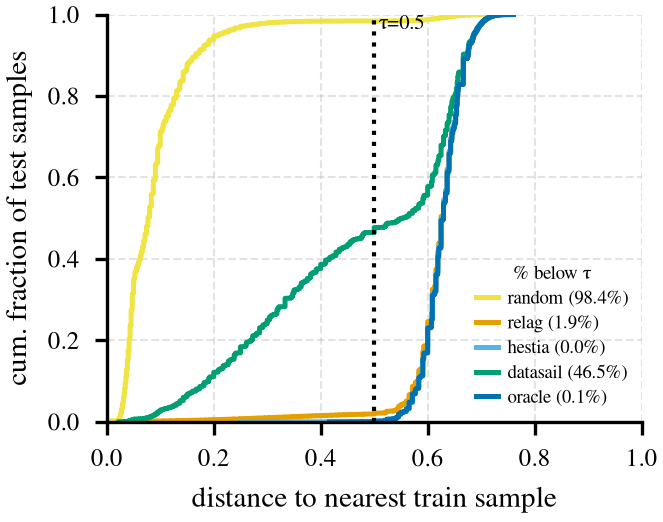

In [27]:
# ---- Figure 2: leakage ECDF ---------------------------------------------------
# ECDF of each test sample's distance to its nearest train sample, pooled over
# repeats; everything left of the dotted tau line violates it.

def plot_leakage_ecdf():
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for method in SYN_METHODS:
        values = np.concatenate([row["values"] for row in synthetic["nn_distances"]
                                 if row["method"] == method])
        x = np.sort(values)
        y = np.arange(1, len(x) + 1) / len(x)
        violating = 100.0 * float((x < SYN_TAU).mean())
        ax.plot(x, y, color=SYN_COLOR[method], linewidth=1.2,
                label=f"{syn_name(method)} ({violating:.1f}%)")
    ax.axvline(SYN_TAU, color="black", linestyle=":", linewidth=1.0)
    ax.text(SYN_TAU, 1.0, f" τ={SYN_TAU}", fontsize=5, va="top", ha="left")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("distance to nearest train sample", fontsize=7)
    ax.set_ylabel("cum. fraction of test samples", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=4.5, handlelength=1.2, labelspacing=0.3, loc="lower right",
              title="% below τ", title_fontsize=4.5)
    fig.tight_layout()
    return fig

fig = plot_leakage_ecdf()
plt.show()
save_fig(fig, "synthetic_leakage_ecdf")

          mean gap  median gap  max |gap|
random       0.123       0.124      0.163
relag        0.005       0.006      0.106
hestia      -0.004      -0.004      0.104
datasail     0.004       0.009      0.083
oracle      -0.006      -0.006      0.077


/tmp/ipykernel_1596178/1834947173.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


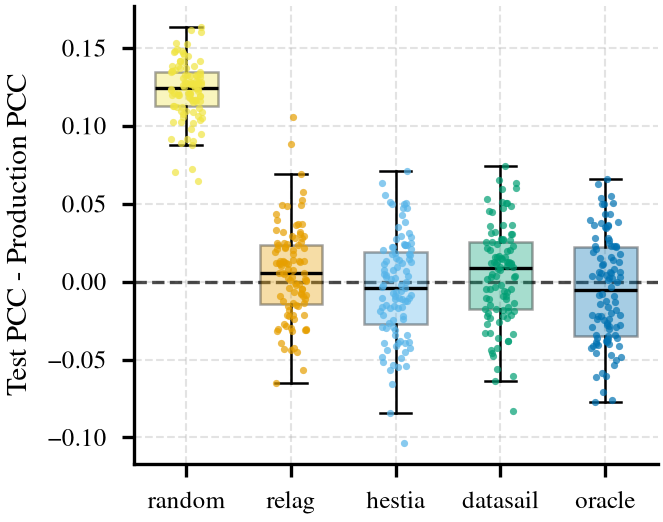

In [28]:
# ---- Figure 3: eval faithfulness ---------------------------------------------
# Test PCC - Production PCC per method: box = spread over repeats, one point per
# repeat overlaid. 0 = the test split predicts real-world performance exactly.

def plot_eval_gap():
    gaps = [(syn_records[syn_records["method"] == m]["test_pcc"]
             - syn_records[syn_records["method"] == m]["production_pcc"]).values
            for m in SYN_METHODS]
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    boxes = ax.boxplot(gaps, positions=range(len(SYN_METHODS)), widths=0.6,
                       patch_artist=True, showfliers=False, zorder=2,
                       medianprops={"color": "black", "linewidth": 0.8},
                       whiskerprops={"linewidth": 0.6}, capprops={"linewidth": 0.6},
                       boxprops={"linewidth": 0.6})
    for patch, method in zip(boxes["boxes"], SYN_METHODS):
        patch.set_facecolor(SYN_COLOR[method])
        patch.set_alpha(0.35)
    rng = np.random.default_rng(0)
    for i, (method, values) in enumerate(zip(SYN_METHODS, gaps)):
        jitter = rng.uniform(-0.15, 0.15, len(values))
        ax.scatter(np.full(len(values), i) + jitter, values, s=3, alpha=0.7,
                   color=SYN_COLOR[method], linewidths=0, zorder=3)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7, zorder=1)
    ax.set_xticks(range(len(SYN_METHODS)))
    ax.set_xticklabels([syn_name(m) for m in SYN_METHODS], fontsize=6)
    ax.set_ylabel("Test PCC - Production PCC", fontsize=7)
    ax.tick_params(labelsize=6)
    fig.tight_layout()

    summary = pd.DataFrame({syn_name(m): {"mean gap": g.mean(), "median gap": np.median(g),
                                          "max |gap|": np.abs(g).max()}
                            for m, g in zip(SYN_METHODS, gaps)}).T
    print(summary.round(3))
    return fig

fig = plot_eval_gap()
plt.show()
save_fig(fig, "synthetic_eval_gap")

--- synthetic_15000_1000_d10_e3 ---
acceptance plateau (KS p > 0.05): τ ∈ [0.3, 0.7]   width 0.40
KS-minimising τ: 0.4 (KS=0.0290)
chosen τ: 0.5

    τ       KS         p  communities  hybrid  verdict
 0.00   0.9838  0.00e+00       29,958       0  differ
 0.05   0.9786  0.00e+00       23,233       0  differ
 0.10   0.9574  0.00e+00       12,999       0  differ
 0.15   0.8306  0.00e+00        5,368       0  differ
 0.20   0.5023  0.00e+00        2,966       0  differ
 0.25   0.1592  7.86e-13        2,248       0  differ
 0.30   0.0413  3.17e-01        2,120       0  same
 0.35   0.0296  7.40e-01        2,081       0  same
 0.40   0.0290  7.64e-01        2,074       0  same
 0.45   0.0290  7.64e-01        2,074       0  same
 0.50   0.0293  7.77e-01        2,011      30  same <-- chosen
 0.55   0.0418  4.95e-01        1,598      47  same
 0.60   0.0530  5.88e-01          896      68  same
 0.65   0.1303  2.07e-01          445     180  same
 0.70   0.2239  6.12e-02          515     374  s

/tmp/ipykernel_1596178/3097868569.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_1596178/3097868569.py:62: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


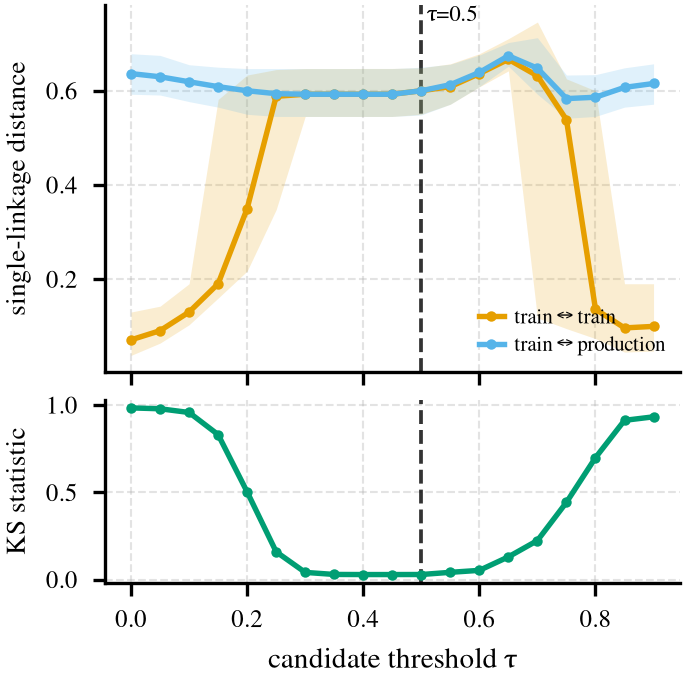

In [29]:
# ---- Figure 4: how tau is chosen on the synthetic forest ---------------------
# The threshold sweep asks, at each candidate tau: do train->train and
# train->production single-linkage distances come from the same distribution?
# If they do, the communities found at that tau generalise -- a held-out
# neighbour is no closer than a genuinely unseen one.
#
# (a) the two distance distributions (median, p15-p85) converging as tau rises.
# (b) the KS statistic testing that convergence, log scale.
# Shaded band = the acceptance plateau, every tau where the KS test FAILS to
# reject equality (p > 0.05). Any tau in that band is defensible; we take 0.5.

SYN_THRESHOLD_FILE = "synthetic_15000_1000_d10_e3"
KS_ALPHA = 0.05

def _load_sweep(name: str) -> dict:
    """Local loader so this cell does not depend on the earlier threshold cell."""
    with open(Path("..") / "results" / "thresholds" / f"{name}.json") as f:
        return json.load(f)

def plot_threshold_convergence(name: str = SYN_THRESHOLD_FILE, chosen: float = SYN_TAU):
    d = _load_sweep(name)
    results = sorted(d["results"], key=lambda r: r["threshold"])
    tau = np.array([r["threshold"] for r in results])
    ks = np.array([r["ks_stat"] for r in results])
    pval = np.array([r["ks_pvalue"] for r in results])

    # contiguous run of tau values where the test fails to reject equality
    accepted = pval > KS_ALPHA
    plateau = (tau[accepted].min(), tau[accepted].max()) if accepted.any() else None

    colors = method_colors(["refnd", "hestia"])
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(FIG_W, FIG_H * 1.25), sharex=True,
        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.1})

    for ax in (ax_top, ax_bot):
        # if plateau is not None:
        #     ax.axvspan(*plateau, color="grey", alpha=0.12, linewidth=0, zorder=0)
        ax.axvline(chosen, color="black", linestyle="--", linewidth=0.9, alpha=0.8, zorder=1)
        ax.tick_params(labelsize=6)

    # (a) the two distributions converging
    for key, label, color in (("train_train", "train ↔ train", colors["refnd"]),
                              ("train_prod", "train ↔ production", colors["hestia"])):
        median = np.array([r[key]["median"] for r in results])
        p15 = np.array([r[key]["p15"] for r in results])
        p85 = np.array([r[key]["p85"] for r in results])
        ax_top.plot(tau, median, color=color, linewidth=1.3, marker="o", markersize=2.5,
                    label=label, zorder=3)
        ax_top.fill_between(tau, p15, p85, color=color, alpha=0.18, linewidth=0, zorder=2)
    ax_top.set_ylabel("single-linkage distance", fontsize=6.5)
    ax_top.legend(fontsize=5, handlelength=1.2, labelspacing=0.3, loc="lower right")
    ax_top.text(chosen, ax_top.get_ylim()[1], f" τ={chosen:g}", fontsize=5.5,
                va="top", ha="left")

    # (b) the test behind it
    ax_bot.plot(tau, np.maximum(ks, 1e-3), color=_cycle_colors[2], linewidth=1.3,
                marker="o", markersize=2.5, zorder=3)
    ax_bot.set_ylabel("KS statistic", fontsize=6.5)
    ax_bot.set_xlabel("candidate threshold τ", fontsize=7)

    fig.tight_layout()

    print(f"--- {name} ---")
    if plateau is not None:
        print(f"acceptance plateau (KS p > {KS_ALPHA}): τ ∈ [{plateau[0]:g}, {plateau[1]:g}]"
              f"   width {plateau[1] - plateau[0]:.2f}")
    print(f"KS-minimising τ: {tau[np.argmin(ks)]:g} (KS={ks.min():.4f})")
    print(f"chosen τ: {chosen:g}\n")
    print(f"{'τ':>5} {'KS':>8} {'p':>9} {'communities':>12} {'hybrid':>7}  verdict")
    for r, p in zip(results, pval):
        mark = "same" if p > KS_ALPHA else "differ"
        star = " <-- chosen" if abs(r["threshold"] - chosen) < 1e-9 else ""
        print(f"{r['threshold']:>5.2f} {r['ks_stat']:>8.4f} {p:>9.2e} "
              f"{r['n_communities']:>12,} {r['n_hybrid']:>7,}  {mark}{star}")
    return fig, (ax_top, ax_bot)

fig, axes = plot_threshold_convergence()
plt.show()
save_fig(fig, "synthetic_threshold_convergence")


              train_in_shared_family[%]       test_in_shared_family[%]        \
                                   mean   std                     mean   std   
method                                                                         
datasail                          21.01  2.50                    51.56  5.43   
family_oracle                      0.00  0.00                     0.00  0.00   
hestia                             0.00  0.00                     0.00  0.00   
random                            93.80  0.61                    98.40  0.19   
refnd                              0.62  0.53                     2.60  2.28   

              n_shared_families         
                           mean    std  
method                                  
datasail                  140.6  16.02  
family_oracle               0.0   0.00  
hestia                      0.0   0.00  
random                    668.0  15.00  
refnd                       5.1   2.51  


/tmp/ipykernel_1596178/700922101.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


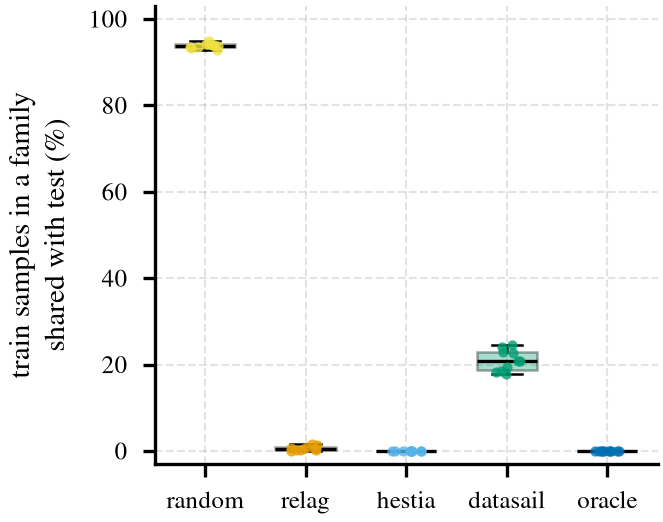

In [30]:
# ---- Figure 5: family-level leakage -------------------------------------------
# Results of synthetic/family_leakage.py (10 repeats, regenerated splits): % of
# train samples whose TRUE family also has members in test. 0 = families kept
# whole (oracle); random splits put nearly every family on both sides.

with open(Path("..") / "results" / "synthetic" / f"family_leakage_tau{SYN_TAU_FILE:g}.json") as f:
    syn_family = pd.DataFrame([r for r in json.load(f)["records"] if r["error"] is None])

def plot_family_leakage(key: str = "train_in_shared_family[%]"):
    values = [syn_family.loc[syn_family["method"] == m, key].values for m in SYN_METHODS]
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    boxes = ax.boxplot(values, positions=range(len(SYN_METHODS)), widths=0.6,
                       patch_artist=True, showfliers=False, zorder=2,
                       medianprops={"color": "black", "linewidth": 0.8},
                       whiskerprops={"linewidth": 0.6}, capprops={"linewidth": 0.6},
                       boxprops={"linewidth": 0.6})
    for patch, method in zip(boxes["boxes"], SYN_METHODS):
        patch.set_facecolor(SYN_COLOR[method])
        patch.set_alpha(0.35)
    rng = np.random.default_rng(0)
    for i, (method, v) in enumerate(zip(SYN_METHODS, values)):
        ax.scatter(np.full(len(v), i) + rng.uniform(-0.15, 0.15, len(v)), v, s=6,
                   alpha=0.8, color=SYN_COLOR[method], linewidths=0, zorder=3)
    ax.set_xticks(range(len(SYN_METHODS)))
    ax.set_xticklabels([syn_name(m) for m in SYN_METHODS], fontsize=6)
    ax.set_ylabel("train samples in a family\nshared with test (%)", fontsize=7)
    ax.set_ylim(-3, 103)
    ax.tick_params(labelsize=6)
    fig.tight_layout()

    print(syn_family.groupby("method")[["train_in_shared_family[%]", "test_in_shared_family[%]",
                                        "n_shared_families"]].agg(["mean", "std"]).round(2))
    return fig

fig = plot_family_leakage()
plt.show()
save_fig(fig, "synthetic_family_leakage")
